A notebook to run the data from the March 2024 flights through NF2FF, without having to reinterpolate as before

In [1]:
## import statements:
import numpy as np
from matplotlib.pyplot import *
from numpy.fft import fft2
from numpy.fft import ifft2
from numpy.fft import fftshift
from numpy.fft import ifftshift
from scipy.interpolate import griddata


import pandas
from matplotlib.colors import LogNorm

from scipy.interpolate import RectBivariateSpline

import NF2FF as nf

import pykrige.kriging_tools as kt
from pykrige.ok import OrdinaryKriging

In [2]:
font = {'family' : 'normal',
        'size'   : 12}

matplotlib.rc('font', **font)

In [3]:
dat=np.load("../cplxEfield_04112024.npz")
for key in dat.keys():
    print(key)

cplxEfieldNS_interped
cplxEfieldEW_interped
x
y
freq


In [4]:
NF_EW_Complex=dat['cplxEfieldEW_interped']
NF_NS_Complex=dat['cplxEfieldNS_interped']
NF_x = dat['x']
NF_y = dat['y']
freq = dat['freq']

print(NF_EW_Complex.shape)
print(NF_NS_Complex.shape)
print(NF_x.shape)
print(NF_y.shape)

(53, 53)
(53, 53)
(53, 53)
(53, 53)


Can't use the RegularGridding function for this because of how the data is, so will make the gridding myself in the next cell(s)

In [5]:
NF_x_vector = NF_x[:,0]
NF_y_vector = NF_y[0,:]

print(NF_x_vector)
print(NF_y_vector)

[-3.90996241e+00 -3.75958647e+00 -3.60921053e+00 -3.45883459e+00
 -3.30845865e+00 -3.15808271e+00 -3.00770677e+00 -2.85733083e+00
 -2.70695489e+00 -2.55657895e+00 -2.40620301e+00 -2.25582707e+00
 -2.10545113e+00 -1.95507519e+00 -1.80469925e+00 -1.65432331e+00
 -1.50394737e+00 -1.35357143e+00 -1.20319549e+00 -1.05281955e+00
 -9.02443609e-01 -7.52067669e-01 -6.01691729e-01 -4.51315789e-01
 -3.00939850e-01 -1.50563910e-01 -1.87969925e-04  1.50187970e-01
  3.00563910e-01  4.50939850e-01  6.01315789e-01  7.51691729e-01
  9.02067669e-01  1.05244361e+00  1.20281955e+00  1.35319549e+00
  1.50357143e+00  1.65394737e+00  1.80432331e+00  1.95469925e+00
  2.10507519e+00  2.25545113e+00  2.40582707e+00  2.55620301e+00
  2.70657895e+00  2.85695489e+00  3.00733083e+00  3.15770677e+00
  3.30808271e+00  3.45845865e+00  3.60883459e+00  3.75921053e+00
  3.90958647e+00]
[-3.90996241e+00 -3.75958647e+00 -3.60921053e+00 -3.45883459e+00
 -3.30845865e+00 -3.15808271e+00 -3.00770677e+00 -2.85733083e+00
 -2.706

In [6]:
# checking the spacing between points in the x and y vectors is consistent
print(NF_x_vector[1] - NF_x_vector[0])
print(NF_x_vector[2] - NF_x_vector[1])
print(NF_x_vector[51] - NF_x_vector[50])
print(NF_y_vector[1] - NF_y_vector[0])
print(NF_y_vector[2] - NF_y_vector[1])
print(NF_y_vector[51] - NF_y_vector[50])

0.15037593984962427
0.15037593984962427
0.15037593984962427
0.15037593984962427
0.15037593984962427
0.15037593984962427


In [7]:
# making the gridding

M=NF_EW_Complex.shape[0]
N=NF_EW_Complex.shape[1]
dx = NF_x_vector[1] - NF_x_vector[0]
dy = NF_y_vector[1] - NF_y_vector[0]
dtheta = 0.01 # before was at 0.05
dphi = 0.01

# setting up k-space, theta, phi grids
# See equations (16-13a) and (16-13b) in Balanis
# Zero padding is used to increase the resolution of the plane wave spectral domain.
MI=4*M;#2^(ceil(log2(M))+1);
NI=4*N;#2^(ceil(log2(N))+1);
m=np.linspace(-MI/2,MI/2-1,MI);
n=np.linspace(-NI/2,NI/2-1,NI)
k_X_Rectangular=(2*np.pi*m)/(MI*dx);
k_Y_Rectangular=(2*np.pi*n)/(NI*dy);
theta=np.arange(0,np.pi/2+dtheta,dtheta);
phi=np.arange(0,2*np.pi+dphi,dphi);
[theta,phi]=np.meshgrid(theta,phi);
print(theta)
print(phi)

[[0.   0.01 0.02 ... 1.56 1.57 1.58]
 [0.   0.01 0.02 ... 1.56 1.57 1.58]
 [0.   0.01 0.02 ... 1.56 1.57 1.58]
 ...
 [0.   0.01 0.02 ... 1.56 1.57 1.58]
 [0.   0.01 0.02 ... 1.56 1.57 1.58]
 [0.   0.01 0.02 ... 1.56 1.57 1.58]]
[[0.   0.   0.   ... 0.   0.   0.  ]
 [0.01 0.01 0.01 ... 0.01 0.01 0.01]
 [0.02 0.02 0.02 ... 0.02 0.02 0.02]
 ...
 [6.27 6.27 6.27 ... 6.27 6.27 6.27]
 [6.28 6.28 6.28 ... 6.28 6.28 6.28]
 [6.29 6.29 6.29 ... 6.29 6.29 6.29]]


In [8]:
print(freq)

670.703125


In [9]:
# frequency stuff--frequency comes in Hertz
k0 = nf.Calculate_k0(freq*(10**6))
nyquist_m = nf.NyquistSampling(freq*(10**6))

print(nyquist_m)

0.22349117428072218


<ipython-input-10-ff922f0fa476>:8: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  ax[0][0].pcolormesh(x,y,np.abs(NF_EW_Complex))
<ipython-input-10-ff922f0fa476>:10: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  ax[0][1].pcolormesh(x,y,np.abs(NF_NS_Complex))
<ipython-input-10-ff922f0fa476>:12: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X

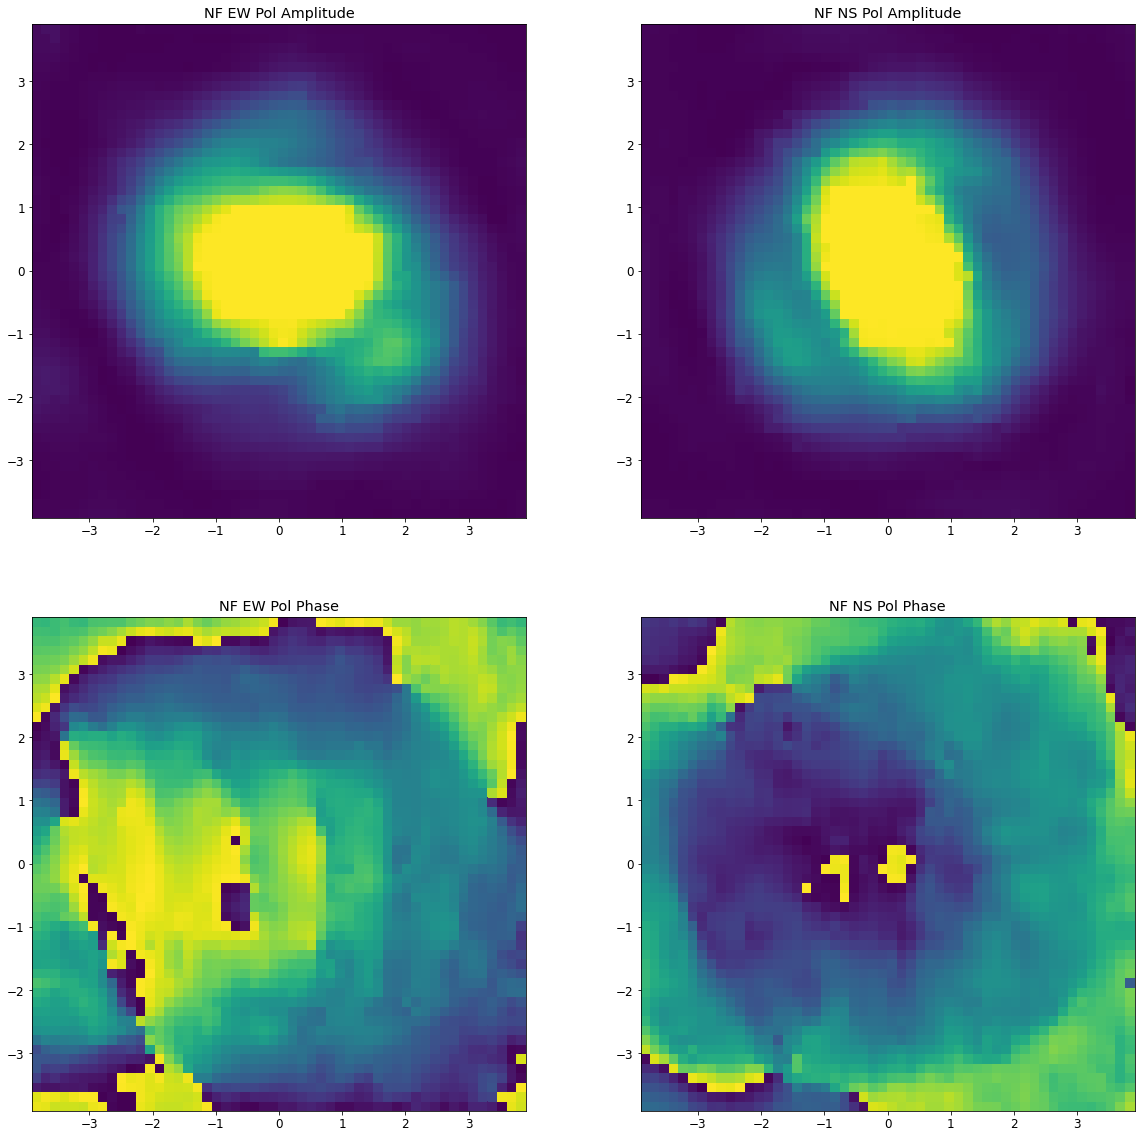

In [10]:
# [x_grid,y_grid]=np.meshgrid(x,y)

x=NF_x
y=NF_y
[x_grid,y_grid]=np.meshgrid(x,y)

fig,ax=subplots(2,2,figsize=(20,20))
ax[0][0].pcolormesh(x,y,np.abs(NF_EW_Complex))
ax[0][0].set_title('NF EW Pol Amplitude')
ax[0][1].pcolormesh(x,y,np.abs(NF_NS_Complex))
ax[0][1].set_title('NF NS Pol Amplitude')
ax[1][0].pcolormesh(x,y,np.angle(NF_EW_Complex))
ax[1][0].set_title('NF EW Pol Phase')
ax[1][1].pcolormesh(x,y,np.angle(NF_NS_Complex))
ax[1][1].set_title('NF NS Pol Phase')
for axis_set in ax:
    for a in axis_set:
        a.set_aspect('equal')

<ipython-input-11-dceeb9094440>:2: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  ax[0][0].pcolormesh(x,y,(NF_EW_Complex.real))
<ipython-input-11-dceeb9094440>:4: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  ax[0][1].pcolormesh(x,y,(NF_EW_Complex.imag))
<ipython-input-11-dceeb9094440>:6: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and

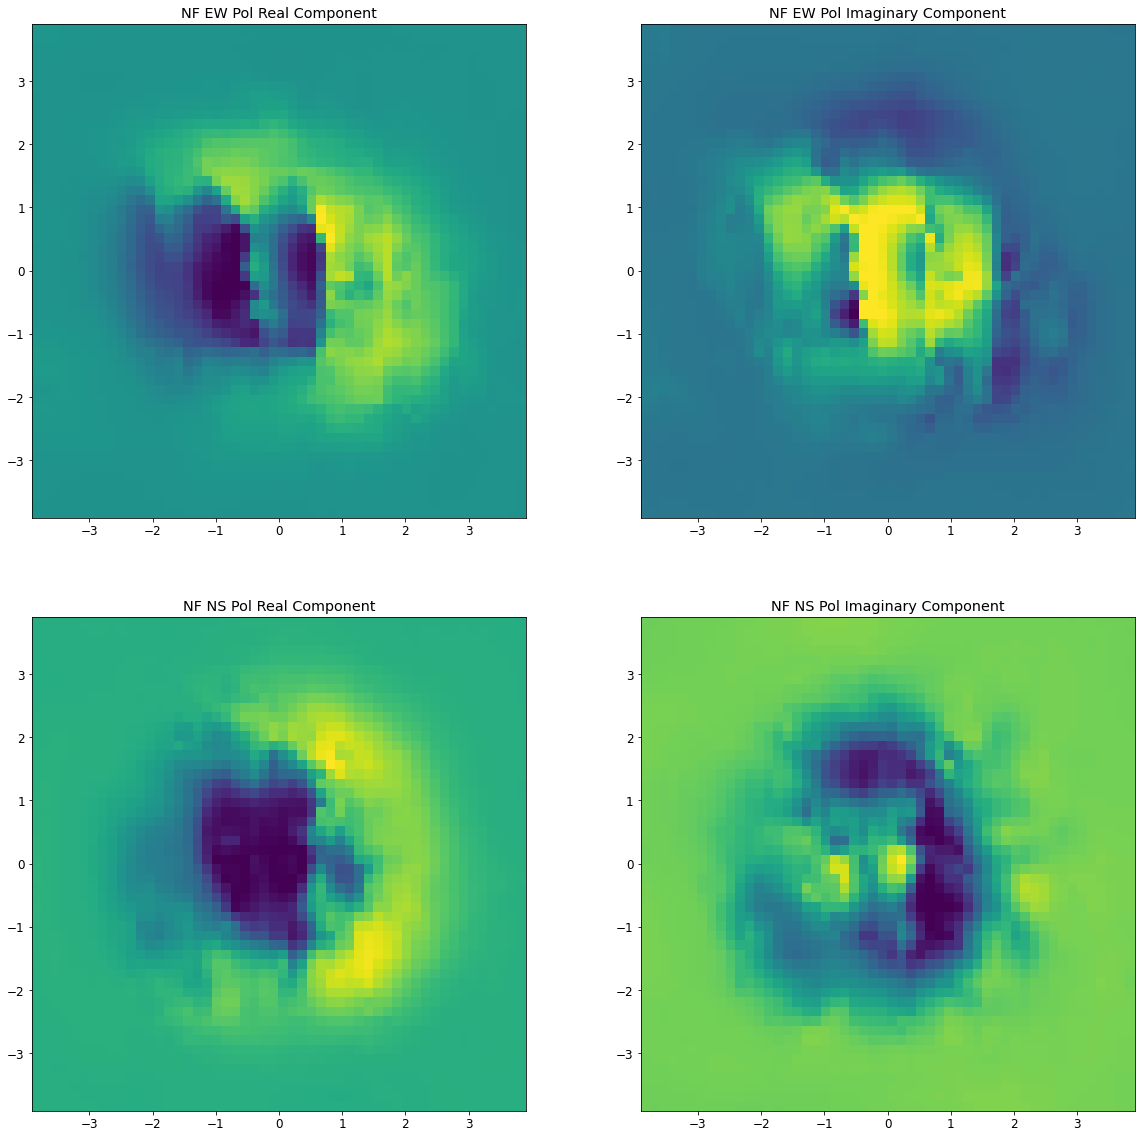

In [11]:
fig,ax=subplots(2,2,figsize=(20,20))
ax[0][0].pcolormesh(x,y,(NF_EW_Complex.real))
ax[0][0].set_title('NF EW Pol Real Component')
ax[0][1].pcolormesh(x,y,(NF_EW_Complex.imag))
ax[0][1].set_title('NF EW Pol Imaginary Component')
ax[1][0].pcolormesh(x,y,(NF_NS_Complex.real))
ax[1][0].set_title('NF NS Pol Real Component')
ax[1][1].pcolormesh(x,y,(NF_NS_Complex.imag))
ax[1][1].set_title('NF NS Pol Imaginary Component')
for axis_set in ax:
    for a in axis_set:
        a.set_aspect('equal')

In [12]:
# looks like a lot of NaNs--checking how many

print(np.count_nonzero(np.isnan(NF_EW_Complex)))
print(np.count_nonzero(np.isnan(NF_NS_Complex)))
print(NF_EW_Complex.shape)
print(6356/86/86)
print(53*53)

0
0
(53, 53)
0.8593834505137913
2809


There are a lot of NaNs and I don't know if NF2FF will like that. I'll just go ahead with it and see what happens I guess?

/home/am3674/NF2FF_WL/NF2FF.py:92: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  ax1.pcolormesh(kx_grid,ky_grid,fx_magnitude,cmap='gnuplot2',norm=LogNorm())
/home/am3674/NF2FF_WL/NF2FF.py:93: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  ax2.pcolormesh(kx_grid,ky_grid,fy_magnitude,cmap='gnuplot2',norm=LogNorm())
/home/am3674/NF2FF_WL/NF2FF.py:94: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3. 

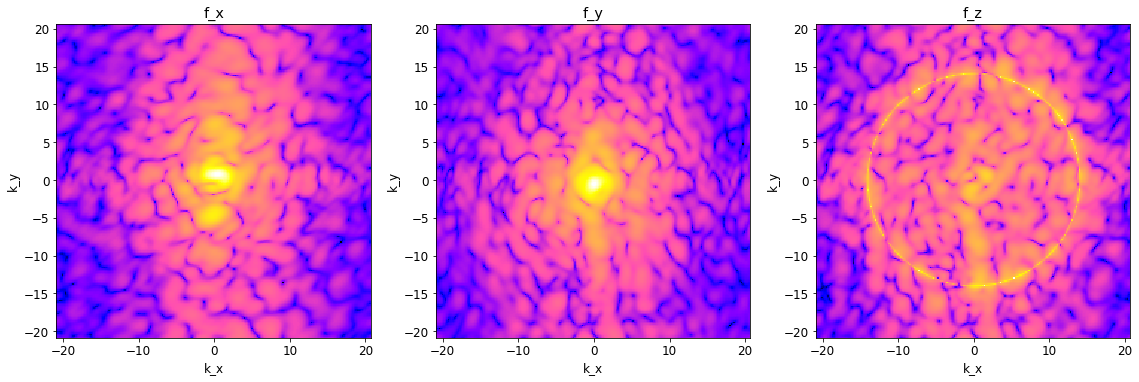

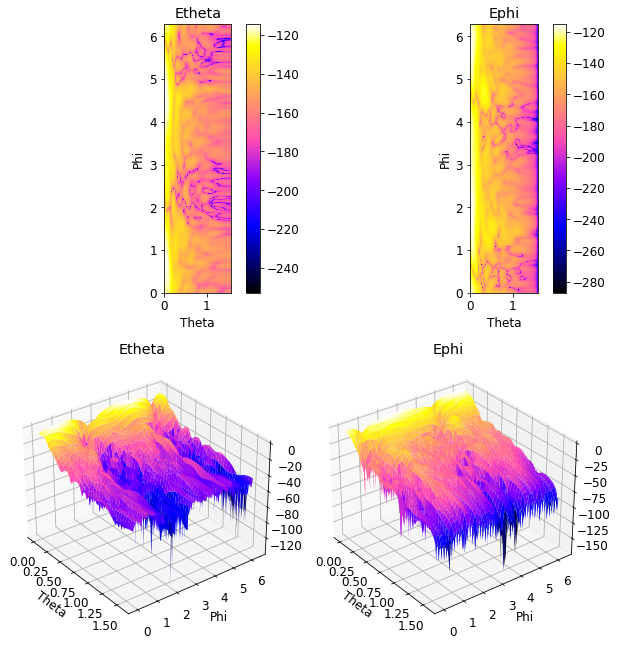

In [13]:
FourierSpace=nf.NFtoFourier(NF_EW_Complex,NF_NS_Complex,k_X_Rectangular,k_Y_Rectangular,k0,plotFourier=True)
[Etheta,Ephi]=nf.FouriertoFF(FourierSpace[0],FourierSpace[1],FourierSpace[2],theta,phi,k_X_Rectangular,k_Y_Rectangular,k0,FFOutputs=True)

## Experimenting with plotting

Trying to find the best way to plot the spherical data, mainly using `pcolormesh` in the polar projection.

In [14]:
Etheta.shape
Ephi.shape
Etheta[:,:].shape

(630, 159)

<ipython-input-15-4f230df37e0c>:2: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  ax[0].pcolormesh(phi[:,:,],theta[:,:], 20*np.log10(np.abs(Etheta[:,:])),cmap='gnuplot2')
<ipython-input-15-4f230df37e0c>:3: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  ax[1].pcolormesh(phi,theta, 20*np.log10(np.abs(Etheta)), cmap='gnuplot2')


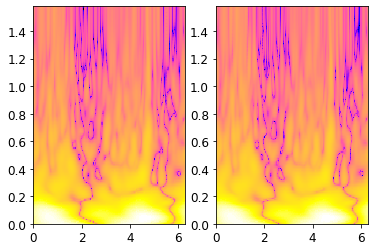

In [15]:
fig, ax = subplots(ncols=2, nrows=1)
ax[0].pcolormesh(phi[:,:,],theta[:,:], 20*np.log10(np.abs(Etheta[:,:])),cmap='gnuplot2')
ax[1].pcolormesh(phi,theta, 20*np.log10(np.abs(Etheta)), cmap='gnuplot2')

<ipython-input-16-cd523f298fe7>:3: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  pcm = pcolormesh(phi,theta,20*np.log10(np.abs(Etheta)),cmap='gnuplot2')
<ipython-input-16-cd523f298fe7>:8: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  pcm = pcolormesh(phi,theta,20*np.log10(np.abs(Ephi)),cmap='gnuplot2')


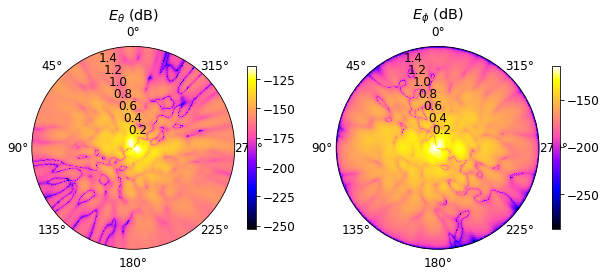

In [16]:
fig = figure(figsize=(10,10))
ax = subplot(1, 2, 1, projection='polar')
pcm = pcolormesh(phi,theta,20*np.log10(np.abs(Etheta)),cmap='gnuplot2')
colorbar(mappable = pcm,shrink = 0.3)
ax.set_title(r'$E_{\theta}$ (dB)')
ax.set_theta_offset(np.pi/2.0)
ax = subplot(1, 2, 2, projection='polar')
pcm = pcolormesh(phi,theta,20*np.log10(np.abs(Ephi)),cmap='gnuplot2')
colorbar(mappable = pcm,shrink = 0.3)
ax.set_title(r'$E_{\phi}$ (dB)')
ax.set_theta_offset(np.pi/2.0)

<ipython-input-42-e7fbcdf550d6>:3: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  pcm = pcolormesh(phi[:,:],theta[:,:],20*np.log10(np.abs(Etheta[:,:])),cmap='gnuplot2')
<ipython-input-42-e7fbcdf550d6>:8: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  pcm = pcolormesh(phi[:,:],theta[:,:],20*np.log10(np.abs(Ephi[:,:])),cmap='gnuplot2')


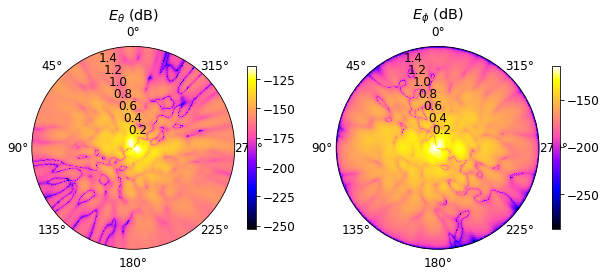

In [42]:
fig = figure(figsize=(10,10))
ax = subplot(1, 2, 1, projection='polar')
pcm = pcolormesh(phi[:,:],theta[:,:],20*np.log10(np.abs(Etheta[:,:])),cmap='gnuplot2')
colorbar(mappable = pcm,shrink = 0.3)
ax.set_title(r'$E_{\theta}$ (dB)')
ax.set_theta_offset(np.pi/2.0)
ax = subplot(1, 2, 2, projection='polar')
pcm = pcolormesh(phi[:,:],theta[:,:],20*np.log10(np.abs(Ephi[:,:])),cmap='gnuplot2')
colorbar(mappable = pcm,shrink = 0.3)
ax.set_title(r'$E_{\phi}$ (dB)')
ax.set_theta_offset(np.pi/2.0)

<ipython-input-43-35e28f44a76a>:4: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  pcm = pcolormesh(phi[:,:],theta[:,:],np.abs(Etheta[:,:]),cmap='gnuplot2')
<ipython-input-43-35e28f44a76a>:9: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  pcm = pcolormesh(phi[:,:],theta[:,:],np.abs(Ephi[:,:]),cmap='gnuplot2')


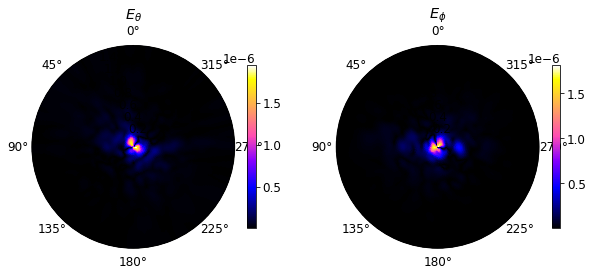

In [43]:
# the same, without log scale
fig = figure(figsize=(10,10))
ax = subplot(1, 2, 1, projection='polar')
pcm = pcolormesh(phi[:,:],theta[:,:],np.abs(Etheta[:,:]),cmap='gnuplot2')
colorbar(mappable = pcm,shrink = 0.3)
ax.set_title(r'$E_{\theta}$')
ax.set_theta_offset(np.pi/2.0)
ax = subplot(1, 2, 2, projection='polar')
pcm = pcolormesh(phi[:,:],theta[:,:],np.abs(Ephi[:,:]),cmap='gnuplot2')
colorbar(mappable = pcm,shrink = 0.3)
ax.set_title(r'$E_{\phi}$')
ax.set_theta_offset(np.pi/2.0)

<ipython-input-54-c70c49f5550e>:3: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  pcm = pcolormesh(phi,theta,20*np.log10(np.abs(Etheta)),cmap='gnuplot2')
<ipython-input-54-c70c49f5550e>:8: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  pcm = pcolormesh(phi,theta,20*np.log10(np.abs(Ephi)),cmap='gnuplot2')


(0.0, 1.0)

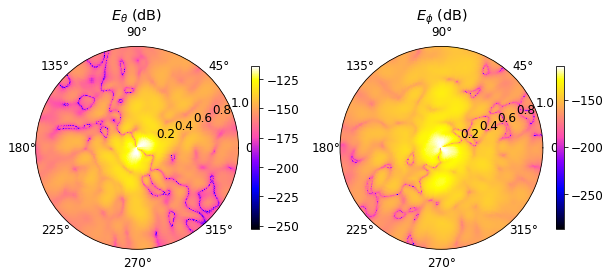

In [54]:
# the difference with this 1 is that the y coordinates (theta) is limited from 0 to 1 (I don't think we want this but I did it)
fig = figure(figsize=(10,10))
ax = subplot(1, 2, 1, projection='polar')
pcm = pcolormesh(phi,theta,20*np.log10(np.abs(Etheta)),cmap='gnuplot2')
colorbar(mappable = pcm,shrink = 0.3)
ax.set_ylim(0,1)
ax.set_title(r'$E_{\theta}$ (dB)')
ax = subplot(1, 2, 2, projection='polar')
pcm = pcolormesh(phi,theta,20*np.log10(np.abs(Ephi)),cmap='gnuplot2')
colorbar(mappable = pcm,shrink = 0.3)
ax.set_title(r'$E_{\phi}$ (dB)')
ax.set_ylim(0,1)

[[0.   0.   0.   ... 0.   0.   0.  ]
 [0.01 0.01 0.01 ... 0.01 0.01 0.01]
 [0.02 0.02 0.02 ... 0.02 0.02 0.02]
 ...
 [6.27 6.27 6.27 ... 6.27 6.27 6.27]
 [6.28 6.28 6.28 ... 6.28 6.28 6.28]
 [6.29 6.29 6.29 ... 6.29 6.29 6.29]]


<ipython-input-45-68835ef128d3>:5: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  pcm = pcolormesh(phi,np.abs(np.sin(theta)),20*np.log10(np.abs(Etheta)),cmap='gnuplot2')
<ipython-input-45-68835ef128d3>:10: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  pcm = pcolormesh(phi,np.abs(np.sin(theta)),20*np.log10(np.abs(Ephi)),cmap='gnuplot2')


(0.0, 1.0)

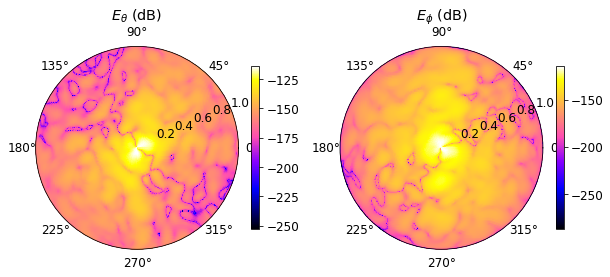

In [45]:
print (phi)
# trying to project from polar onto the xy plane
fig = figure(figsize=(10,10))
ax = subplot(1, 2, 1, projection='polar')
pcm = pcolormesh(phi,np.abs(np.sin(theta)),20*np.log10(np.abs(Etheta)),cmap='gnuplot2')
colorbar(mappable = pcm,shrink = 0.3)
ax.set_title(r'$E_{\theta}$ (dB)')
ax.set_ylim(0,1)
ax = subplot(1, 2, 2, projection='polar')
pcm = pcolormesh(phi,np.abs(np.sin(theta)),20*np.log10(np.abs(Ephi)),cmap='gnuplot2')
colorbar(mappable = pcm,shrink = 0.3)
ax.set_title(r'$E_{\phi}$ (dB)')
ax.set_ylim(0,1)

[]

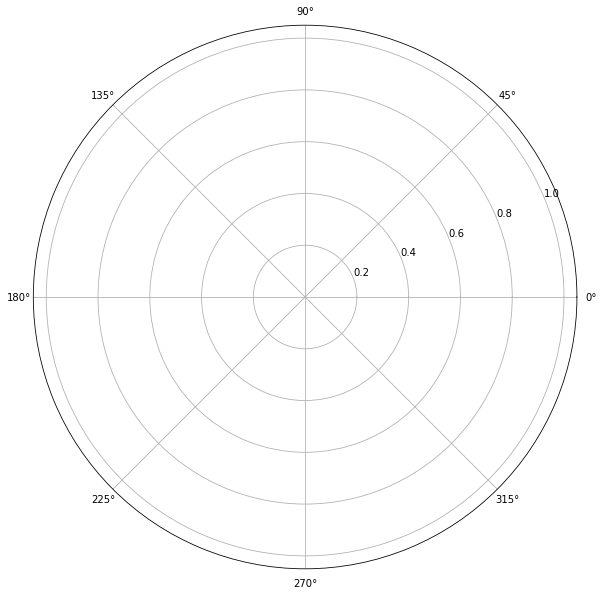

In [139]:
fig = figure(figsize = (10,10))
ax = subplot(1,1,1,projection = 'polar')
data = np.ones(len(theta))
polar()

/home/am3674/anaconda3/lib/python3.8/site-packages/numpy/core/_asarray.py:171: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order, subok=True)


Text(0.5, 0.92, '$E_{\\phi}$ (dB)')

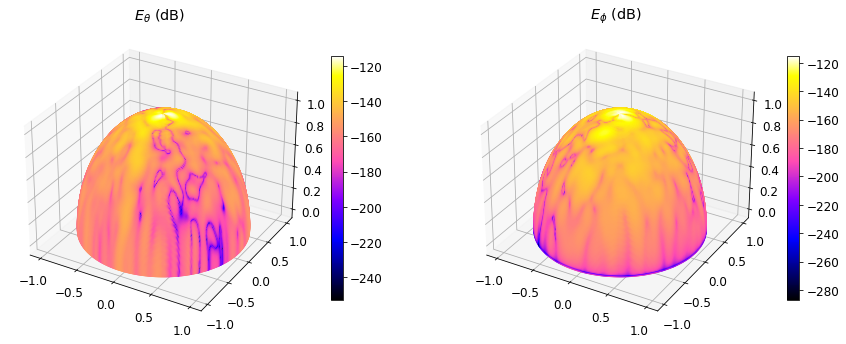

In [46]:
fig = figure(figsize=(15,15))
ax = subplot(1,2,1,projection='3d')

# Create the mesh in polar coordinates and compute corresponding Z.
R = Etheta
# Express the mesh in the cartesian system.
X = np.sin(theta)*np.cos(phi)
Y = np.sin(theta)*np.sin(phi)
Z = np.cos(theta)

# Plot the surface.
pcm = ax.scatter(X, Y, zs=Z,c=20*np.log10(Etheta),cmap='gnuplot2')
colorbar(mappable = pcm,shrink = 0.3)
ax.set_title(r'$E_{\theta}$ (dB)')

ax = subplot(1,2,2,projection='3d')

# Create the mesh in polar coordinates and compute corresponding Z.
R = Ephi
# Express the mesh in the cartesian system.
X = np.sin(theta)*np.cos(phi)
Y = np.sin(theta)*np.sin(phi)
Z = np.cos(theta)

# Plot the surface.
pcm = ax.scatter(X, Y, zs=Z,c=20*np.log10(Ephi),cmap='gnuplot2')
colorbar(mappable = pcm,shrink = 0.3)
ax.set_title(r'$E_{\phi}$ (dB)')

/home/am3674/anaconda3/lib/python3.8/site-packages/matplotlib/colors.py:271: ComplexWarning: Casting complex values to real discards the imaginary part
  c = tuple(map(float, c))
/home/am3674/anaconda3/lib/python3.8/site-packages/numpy/core/_asarray.py:102: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


Text(0.5, 0.92, '$E_{\\phi}$ (dB)')

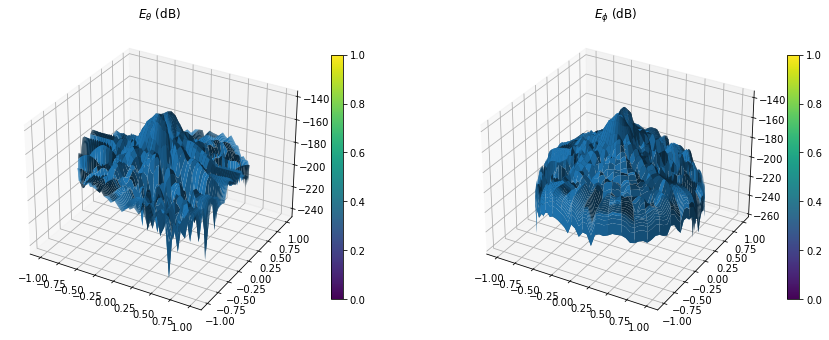

In [141]:
fig = figure(figsize=(15,15))
ax = subplot(1,2,1,projection='3d')

# Create the mesh in polar coordinates and compute corresponding Z.
R = Etheta
# Express the mesh in the cartesian system.
X = np.sin(theta)*np.cos(phi)
Y = np.sin(theta)*np.sin(phi)
Z = np.cos(theta)

# Plot the surface.
pcm = ax.plot_surface(X, Y,20*np.log10(Etheta))
colorbar(mappable = pcm,shrink = 0.3)
ax.set_title(r'$E_{\theta}$ (dB)')

ax = subplot(1,2,2,projection='3d')

# Create the mesh in polar coordinates and compute corresponding Z.
R = Ephi
# Express the mesh in the cartesian system.
X = np.sin(theta)*np.cos(phi)
Y = np.sin(theta)*np.sin(phi)
Z = np.cos(theta)

# Plot the surface.
pcm = ax.plot_surface(X, Y, 20*np.log10(Ephi))
colorbar(mappable = pcm,shrink = 0.3)
ax.set_title(r'$E_{\phi}$ (dB)')